# SENTINEL · Notebook 5 · `ledger/`

**What this notebook builds:** the **Transparency Ledger** from slides 3–5:
> *SHA-256 chain · Merkle root → public anchor · verifier* · *QR/OTP proof of handover* · *Donor QR trace* · *Tamper alarm* · *No personal data on-chain, pseudonymous IDs, role-based views* · *Every manual reallocation ledgered with actor ID*

Every allocation, dispatch, handover, payment and override from Notebook 4 becomes a **signed, chained record**. Then we try to cheat it, twice, and watch it get caught.

### How to use it
Tap **☰ → Runtime → Run all**, keep your screen on, and allow Google Drive access.
**Step 9 (public anchor)** needs free test tokens the first time. It will tell you exactly what to do, and everything else works without it.

## Step 1 · Install the tools and load the results
- **cryptography**: digital signatures (Ed25519)
- **qrcode**: QR codes for handover and donor receipts
- **web3**: talks to the Polygon Amoy test blockchain

In [1]:
!pip install -q web3 "qrcode[pil]" cryptography
import json, os, sys, importlib, shutil, random
import pandas as pd
import qrcode
from IPython.display import display
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/SENTINEL"
DATA_DIR, KEY_DIR = f"{BASE}/data", f"{BASE}/keys"
os.makedirs(f"{BASE}/code/ledger", exist_ok=True)
os.makedirs(KEY_DIR, exist_ok=True)
sys.path.insert(0, f"{BASE}/code/ledger")

if not os.path.exists(f"{DATA_DIR}/results.json"):
    print("❌ results.json not found → finish Notebook 4 first (all steps including Step 13).")
else:
    with open(f"{DATA_DIR}/results.json") as f:
        R = json.load(f)
    with open(f"{DATA_DIR}/scenario.json") as f:
        S = json.load(f)
    allocations = sorted(R["allocations"]["sentinel"], key=lambda a: (a["dispatch_min"], a["patient"]))
    print(f"✅ Step 1 done: {len(allocations)} SENTINEL allocations, {len(S['donations'])} donations, "
          f"{len(R['override_log'])} override(s) to record")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.3/586.3 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.6/385.6 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.8/176.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.8/47.8 kB 2.7 MB/s eta 0:00:00
Mounted at /content/drive
✅ Step 1 done: 55 SENTINEL allo

## Step 2 · How the ledger catches cheating

| Idea | What it means | What it catches |
|---|---|---|
| **SHA-256 hash** | a 64-character fingerprint of a record; change one character and the fingerprint changes completely | any edit to a record |
| **Hash chain** | each record's fingerprint also includes the previous record's fingerprint: $h_n = \text{SHA-256}(\text{record}_n \,\Vert\, h_{n-1})$ | editing, deleting or reordering past records |
| **Signature** | each actor (hospital, control room, finance…) signs its records with its own private key | someone writing records in another actor's name |
| **Merkle root** | one fingerprint that summarises a whole batch of records | lets a donor prove *their* record is included with a tiny proof |
| **Public anchor** | the Merkle roots are published on a public blockchain (Polygon Amoy testnet), where nobody can change them | even an insider who rewrites the whole database |
| **Append-only table** | the database refuses UPDATE and DELETE | casual edits |
| **Pseudonyms** | patients appear as `PT-xxxxxxxxxx`, never by name or ID | privacy (DPDP Act 2023) |

## Step 3 · Save the Ledger Model as a file
Saves **Drive → SENTINEL → code → ledger → ledger_model.py**. It says **"Writing…"** when done.

In [2]:
%%writefile /content/drive/MyDrive/SENTINEL/code/ledger/ledger_model.py
# SENTINEL ledger/ · Tamper-evident ledger
#   hash_n = SHA-256(record_n ‖ hash_{n−1}) · Ed25519 signature per actor role
#   Merkle root per batch → public anchor (Polygon Amoy testnet) · verifier · no personal data
import hashlib
import json
import sqlite3
from cryptography.hazmat.primitives.asymmetric.ed25519 import Ed25519PrivateKey

GENESIS = "0" * 64


def canonical(obj):
    return json.dumps(obj, sort_keys=True, separators=(",", ":"), ensure_ascii=False)


def sha256_hex(text):
    return hashlib.sha256(text.encode()).hexdigest()


def pseudonym(real_id, salt, prefix="PT"):
    # One-way pseudonym: the ledger never stores the real ID, name or phone number
    return f"{prefix}-{sha256_hex(salt + real_id)[:10]}"


def otp_hash(otp, trip_id):
    # The ledger stores only a hash of the handover OTP, never the OTP itself
    return sha256_hex(f"{otp}:{trip_id}")


class Signer:
    # One Ed25519 key per actor role: optimizer, control room, hospital, finance, commander, donor portal
    def __init__(self):
        self.keys = {}

    def _key(self, role):
        if role not in self.keys:
            self.keys[role] = Ed25519PrivateKey.generate()
        return self.keys[role]

    def sign(self, role, message):
        return self._key(role).sign(message.encode()).hex()

    def save(self, path):
        from cryptography.hazmat.primitives import serialization as ser
        raw = {r: k.private_bytes(ser.Encoding.Raw, ser.PrivateFormat.Raw, ser.NoEncryption()).hex()
               for r, k in self.keys.items()}
        with open(path, "w") as f:
            json.dump(raw, f)

    def load(self, path):
        with open(path) as f:
            for r, h in json.load(f).items():
                self.keys[r] = Ed25519PrivateKey.from_private_bytes(bytes.fromhex(h))
        return self

    def verify(self, role, message, signature_hex):
        try:
            self._key(role).public_key().verify(bytes.fromhex(signature_hex), message.encode())
            return True
        except Exception:
            return False


def merkle_root(hashes):
    level = list(hashes) or [GENESIS]
    while len(level) > 1:
        if len(level) % 2:
            level.append(level[-1])
        level = [sha256_hex(level[i] + level[i + 1]) for i in range(0, len(level), 2)]
    return level[0]


def merkle_proof(hashes, index):
    # The sibling hashes needed to recompute the root from one record
    proof, level, i = [], list(hashes), index
    while len(level) > 1:
        if len(level) % 2:
            level.append(level[-1])
        sib = i ^ 1
        proof.append({"hash": level[sib], "side": "left" if sib < i else "right"})
        level = [sha256_hex(level[k] + level[k + 1]) for k in range(0, len(level), 2)]
        i //= 2
    return proof


def verify_proof(leaf, proof, root):
    h = leaf
    for step in proof:
        h = sha256_hex(step["hash"] + h) if step["side"] == "left" else sha256_hex(h + step["hash"])
    return h == root


SCHEMA = """
CREATE TABLE IF NOT EXISTS ledger (
    seq INTEGER PRIMARY KEY, minute REAL, type TEXT, actor_role TEXT,
    payload TEXT, prev_hash TEXT, hash TEXT, signature TEXT);
CREATE TRIGGER IF NOT EXISTS ledger_no_update BEFORE UPDATE ON ledger
    BEGIN SELECT RAISE(ABORT, 'ledger is append-only'); END;
CREATE TRIGGER IF NOT EXISTS ledger_no_delete BEFORE DELETE ON ledger
    BEGIN SELECT RAISE(ABORT, 'ledger is append-only'); END;
CREATE TABLE IF NOT EXISTS batches (
    batch INTEGER PRIMARY KEY, first_seq INTEGER, last_seq INTEGER, merkle_root TEXT, anchor TEXT);
"""


class Ledger:
    def __init__(self, path, signer):
        self.db = sqlite3.connect(path)
        self.db.executescript(SCHEMA)
        self.signer = signer

    def last(self):
        row = self.db.execute("SELECT seq, hash FROM ledger ORDER BY seq DESC LIMIT 1").fetchone()
        return row if row else (0, GENESIS)

    def append(self, minute, rtype, actor_role, payload):
        seq, prev = self.last()
        body = {"seq": seq + 1, "minute": round(float(minute), 1), "type": rtype,
                "actor_role": actor_role, "payload": payload}
        h = sha256_hex(canonical(body) + prev)                 # hash_n = SHA-256(record_n ‖ hash_{n−1})
        sig = self.signer.sign(actor_role, h)
        self.db.execute("INSERT INTO ledger VALUES (?,?,?,?,?,?,?,?)",
                        (seq + 1, body["minute"], rtype, actor_role, canonical(payload), prev, h, sig))
        self.db.commit()
        return seq + 1, h

    def rows(self):
        cur = self.db.execute("SELECT seq, minute, type, actor_role, payload, prev_hash, hash, signature FROM ledger ORDER BY seq")
        return [{"seq": r[0], "minute": r[1], "type": r[2], "actor_role": r[3], "payload": json.loads(r[4]),
                 "prev_hash": r[5], "hash": r[6], "signature": r[7]} for r in cur]

    def verify_chain(self):
        # Recompute every hash, check every link and every signature
        prev = GENESIS
        for r in self.rows():
            body = {"seq": r["seq"], "minute": r["minute"], "type": r["type"],
                    "actor_role": r["actor_role"], "payload": r["payload"]}
            if r["prev_hash"] != prev:
                return False, r["seq"], "link to previous record broken"
            if sha256_hex(canonical(body) + prev) != r["hash"]:
                return False, r["seq"], "record content does not match its hash"
            if not self.signer.verify(r["actor_role"], r["hash"], r["signature"]):
                return False, r["seq"], "signature invalid"
            prev = r["hash"]
        return True, None, "all records, links and signatures valid"

    def seal_batch(self):
        # Merkle root over all records since the last batch
        last = self.db.execute("SELECT MAX(last_seq) FROM batches").fetchone()[0] or 0
        rows = [r for r in self.rows() if r["seq"] > last]
        if not rows:
            return None
        root = merkle_root([r["hash"] for r in rows])
        n = (self.db.execute("SELECT COUNT(*) FROM batches").fetchone()[0] or 0) + 1
        self.db.execute("INSERT INTO batches VALUES (?,?,?,?,?)", (n, rows[0]["seq"], rows[-1]["seq"], root, None))
        self.db.commit()
        return n, root

    def batches(self):
        cur = self.db.execute("SELECT batch, first_seq, last_seq, merkle_root, anchor FROM batches ORDER BY batch")
        return [{"batch": r[0], "first_seq": r[1], "last_seq": r[2], "merkle_root": r[3], "anchor": r[4]} for r in cur]

    def recompute_roots(self):
        rows = {r["seq"]: r["hash"] for r in self.rows()}
        return {b["batch"]: merkle_root([rows[s] for s in range(b["first_seq"], b["last_seq"] + 1) if s in rows])
                for b in self.batches()}

    def proof_for(self, seq):
        rows = {r["seq"]: r["hash"] for r in self.rows()}
        for b in self.batches():
            if b["first_seq"] <= seq <= b["last_seq"]:
                hashes = [rows[s] for s in range(b["first_seq"], b["last_seq"] + 1)]
                return rows[seq], merkle_proof(hashes, seq - b["first_seq"]), b
        return None


def role_view(role, record, viewer_hospital=None, viewer_donation=None):
    # Privacy controls: the same record looks different to each role
    p = record["payload"]
    if role == "Commander":
        return record
    if role == "Hospital":
        if p.get("hospital") == viewer_hospital:
            return record
        return {"seq": record["seq"], "type": record["type"], "hidden": "another hospital's record"}
    if role == "Donor":
        if p.get("donation") == viewer_donation:
            keep = {k: p[k] for k in ["donation", "category", "amount", "trip", "hospital", "delivered_verified"] if k in p}
            return {"seq": record["seq"], "type": record["type"], "payload": keep, "hash": record["hash"]}
        return {"seq": record["seq"], "type": record["type"], "hidden": "not your donation"}
    return {"seq": record["seq"], "type": record["type"], "minute": record["minute"], "hash": record["hash"][:16] + "…"}


# ---------- Public anchor on Polygon Amoy testnet ----------
AMOY_RPC = "https://rpc-amoy.polygon.technology"
AMOY_CHAIN_ID = 80002
AMOY_EXPLORER = "https://amoy.polygonscan.com/tx/"


def anchor_on_amoy(private_key_hex, roots_hex):
    # Sends ONE transaction to yourself whose data field holds all batch Merkle roots
    from web3 import Web3
    from eth_account import Account
    w3 = Web3(Web3.HTTPProvider(AMOY_RPC, request_kwargs={"timeout": 30}))
    if not w3.is_connected():
        return None, "could not reach the Polygon Amoy network"
    acct = Account.from_key(private_key_hex)
    if w3.eth.get_balance(acct.address) == 0:
        return None, "wallet has 0 test POL: get free test POL from a faucet first"
    base = w3.eth.get_block("latest").get("baseFeePerGas", w3.to_wei(30, "gwei"))
    tip = max(w3.eth.max_priority_fee, w3.to_wei(30, "gwei"))
    data = "0x" + "".join(roots_hex)
    tx = {"to": acct.address, "value": 0, "data": data, "chainId": AMOY_CHAIN_ID,
          "nonce": w3.eth.get_transaction_count(acct.address),
          "maxPriorityFeePerGas": tip, "maxFeePerGas": 2 * base + tip}
    tx["gas"] = int(w3.eth.estimate_gas(tx) * 1.2)
    signed = acct.sign_transaction(tx)
    tx_hash = w3.eth.send_raw_transaction(signed.raw_transaction).hex()
    if not tx_hash.startswith("0x"):
        tx_hash = "0x" + tx_hash
    w3.eth.wait_for_transaction_receipt(tx_hash, timeout=180)
    return tx_hash, "anchored"


def read_anchor_from_amoy(tx_hash):
    # Reads the roots back from the public blockchain (anyone can do this)
    from web3 import Web3
    w3 = Web3(Web3.HTTPProvider(AMOY_RPC, request_kwargs={"timeout": 30}))
    data = w3.eth.get_transaction(tx_hash)["input"]
    data = data.hex() if hasattr(data, "hex") else str(data)
    data = data[2:] if data.startswith("0x") else data
    return [data[i:i + 64] for i in range(0, len(data), 64)]

Writing /content/drive/MyDrive/SENTINEL/code/ledger/ledger_model.py


## Step 4 · Write every decision into the ledger
For each patient SENTINEL moved, five kinds of record are written in time order:
`ALLOCATE` (optimiser) → `DISPATCH` (control room, with a hashed OTP) → `HANDOVER` (hospital confirms OTP) → `SPEND` (finance: which donation paid for what).
Donations (`DONATION_RECEIVED`) and human overrides (`OVERRIDE`, with actor ID) are recorded too.
A **Merkle batch** is sealed every 15 minutes of disaster time.

In [3]:
import ledger_model as lm
importlib.reload(lm)

DB = f"{DATA_DIR}/sentinel_ledger.db"
if os.path.exists(DB):
    os.remove(DB)                     # start fresh each run so records are not duplicated
signer = lm.Signer()
ledger = lm.Ledger(DB, signer)
rng = random.Random(7)
SALT = "sentinel-demo-salt"           # in production this is a secret kept outside the ledger
vault, otps = {}, {}                  # vault: pseudonym → real ID (private, never on the ledger)

pools = [{"id": d["id"], "earmark": d["earmark"], "left": d["amount"]} for d in S["donations"]]
def draw(category, amount):
    # Pay from donations earmarked for this category first, then from the 'any' pool
    out = []
    for pool in [p for p in pools if p["earmark"] == category] + [p for p in pools if p["earmark"] == "any"]:
        take = min(pool["left"], amount)
        if take > 0:
            pool["left"] -= take
            amount -= take
            out.append((pool["id"], take))
        if amount <= 0:
            break
    if amount > 0:
        out.append(("UNFUNDED", amount))
    return out

events = []   # (minute, order, type, role, payload)
for d in S["donations"]:
    events.append((0, 0, "DONATION_RECEIVED", "donor_portal",
                   {"donation": d["id"], "donor": d["donor"], "amount": d["amount"], "earmark": d["earmark"]}))
for n, a in enumerate(allocations, start=1):
    trip, pt = f"T{n:03d}", lm.pseudonym(a["patient"], SALT)
    vault[pt] = a["patient"]
    otp = f"{rng.randint(0, 999999):06d}"
    otps[trip] = otp
    events.append((a["dispatch_min"], 1, "ALLOCATE", "optimizer",
                   {"trip": trip, "patient": pt, "triage": a["colour_at_dispatch"], "hospital": a["hospital"],
                    "ambulance": a["ambulance"], "expected_survival": a["survival"]}))
    events.append((a["dispatch_min"], 2, "DISPATCH", "control_room",
                   {"trip": trip, "patient": pt, "ambulance": a["ambulance"], "hospital": a["hospital"],
                    "eta_min": a["arrival_min"], "otp_hash": lm.otp_hash(otp, trip)}))
    events.append((a["arrival_min"], 4, "HANDOVER", "hospital",
                   {"trip": trip, "patient": pt, "hospital": a["hospital"], "otp_verified": True}))
    for category, amount in a["costs"].items():
        for donation, part in draw(category, amount):
            if part > 0:
                events.append((a["arrival_min"], 5, "SPEND", "finance",
                               {"trip": trip, "patient": pt, "hospital": a["hospital"], "donation": donation,
                                "category": category, "amount": part, "delivered_verified": True}))
for o in R["override_log"]:
    events.append((o["minute"], 3, "OVERRIDE", "commander",
                   {"patient": lm.pseudonym(o["patient"], SALT), "from": o["from"], "to": o["to"],
                    "actor_id": "commander-01", "reason": o["reason"]}))

events.sort(key=lambda e: (e[0], e[1]))
window = 0
for minute, _, rtype, role, payload in events:
    if minute // 15 > window and ledger.last()[0] > 0:
        ledger.seal_batch()
        window = minute // 15
    ledger.append(minute, rtype, role, payload)
ledger.seal_batch()
signer.save(f"{KEY_DIR}/signer_keys.json")
with open(f"{KEY_DIR}/vault_private.json", "w") as f:
    json.dump(vault, f)

rows = ledger.rows()
print(pd.Series([r["type"] for r in rows]).value_counts().to_string())
print(f"\nTotal records: {len(rows)} · Merkle batches: {len(ledger.batches())}")
print("\nFIRST 4 RECORDS")
for r in rows[:4]:
    print(f"  #{r['seq']} min {r['minute']:>5} {r['type']:<17} hash {r['hash'][:16]}…  prev {r['prev_hash'][:8]}…")
unfunded = sum(r["payload"]["amount"] for r in rows if r["payload"].get("donation") == "UNFUNDED")
print(f"\nUnfunded spending: ₹{unfunded}")
print("✅ Step 4 done")

SPEND                141
ALLOCATE              55
HANDOVER              55
DISPATCH              55
DONATION_RECEIVED      5
OVERRIDE               1

Total records: 312 · Merkle batches: 10

FIRST 4 RECORDS
  #1 min   0.0 DONATION_RECEIVED hash 7d8993c2ff125258…  prev 00000000…
  #2 min   0.0 DONATION_RECEIVED hash 964eb2ed7fa7d7e6…  prev 7d8993c2…
  #3 min   0.0 DONATION_RECEIVED hash 9b6392394cc31bcf…  prev 964eb2ed…
  #4 min   0.0 DONATION_RECEIVED hash fbc191e7e6bd81cf…  prev 9b639239…

Unfunded spending: ₹0
✅ Step 4 done


## Step 5 · Verify the ledger, and try a normal edit
The verifier recomputes every fingerprint, every link and every signature.
Then we try to change a record the normal way, and the database refuses.

In [4]:
ok, bad_seq, msg = ledger.verify_chain()
print(f"Verifier: {'✅ VALID' if ok else '❌ BROKEN at #' + str(bad_seq)} · {msg}")
try:
    ledger.db.execute("UPDATE ledger SET payload = '{}' WHERE seq = 5")
    print("Edit went through (this should not happen)")
except Exception as e:
    print(f"Trying to edit record #5 → blocked: {e}")
print("✅ Step 5 done")

Verifier: ✅ VALID · all records, links and signatures valid
Trying to edit record #5 → blocked: ledger is append-only
✅ Step 5 done


## Step 6 · QR / OTP proof of handover
When an ambulance is dispatched, the crew gets a **6-digit OTP**. The ledger stores only its *hash*.
At the hospital, the desk scans the crew's QR code or types the OTP. Only the right OTP creates a `HANDOVER` record. A wrong one is rejected and logged.

Trip T001: ambulance A05 → H3
  Crew types the right OTP  → ✅ accepted
  Someone types 123456      → ❌ rejected and logged

Handover QR code (the crew shows this at the hospital desk):


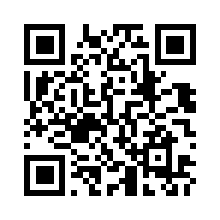

✅ Step 6 done


In [5]:
trip = "T001"
dispatch = next(r for r in rows if r["type"] == "DISPATCH" and r["payload"]["trip"] == trip)

def hospital_confirms(trip, typed_otp, minute):
    good = lm.otp_hash(typed_otp, trip) == dispatch["payload"]["otp_hash"]
    if not good:
        ledger.append(minute, "HANDOVER_REJECTED", "hospital",
                      {"trip": trip, "hospital": dispatch["payload"]["hospital"], "reason": "wrong OTP"})
    return good

print(f"Trip {trip}: ambulance {dispatch['payload']['ambulance']} → {dispatch['payload']['hospital']}")
print(f"  Crew types the right OTP  → {'✅ accepted' if hospital_confirms(trip, otps[trip], dispatch['minute']) else '❌'}")
print(f"  Someone types 123456      → {'✅ accepted' if hospital_confirms(trip, '123456', dispatch['minute']) else '❌ rejected and logged'}")
ledger.seal_batch()
rows = ledger.rows()
print("\nHandover QR code (the crew shows this at the hospital desk):")
display(qrcode.make(f"SENTINEL handover | trip={trip} | otp={otps[trip]}").resize((220, 220)))
print("✅ Step 6 done")

## Step 7 · Attack 1: an insider edits a payment
Someone with database access switches off the protection and changes the amount of one payment.
We do this on a **copy** of the ledger, so the real one stays clean.

In [6]:
spend = next(r for r in rows if r["type"] == "SPEND")
COPY1 = f"{DATA_DIR}/tamper_copy_1.db"
shutil.copy(DB, COPY1)
attacked = lm.Ledger(COPY1, signer)
attacked.db.execute("DROP TRIGGER ledger_no_update")
fake = dict(spend["payload"], amount=spend["payload"]["amount"] * 10)
attacked.db.execute("UPDATE ledger SET payload = ? WHERE seq = ?", (lm.canonical(fake), spend["seq"]))
attacked.db.commit()
print(f"Insider changed record #{spend['seq']}: ₹{spend['payload']['amount']} → ₹{fake['amount']}")
ok, bad_seq, msg = attacked.verify_chain()
print(f"Verifier: {'✅ VALID' if ok else '🚨 TAMPER DETECTED at record #' + str(bad_seq)} · {msg}")
print("✅ Step 7 done")

Insider changed record #37: ₹20000 → ₹200000
Verifier: 🚨 TAMPER DETECTED at record #37 · record content does not match its hash
✅ Step 7 done


## Step 8 · Merkle roots and a donor's proof
Each batch gets one **Merkle root**. A donor can check that a payment from their donation is inside a batch using just a few hashes (a *Merkle proof*), without seeing anyone else's records.

In [7]:
batches = ledger.batches()
print(pd.DataFrame([{"batch": b["batch"], "records": f"#{b['first_seq']}–#{b['last_seq']}",
                     "merkle root": b["merkle_root"][:20] + "…"} for b in batches]).to_string(index=False))
leaf, proof, b = ledger.proof_for(spend["seq"])
print(f"\nProof for record #{spend['seq']}: {len(proof)} sibling hashes → recomputed root matches batch {b['batch']}: "
      f"{'✅ yes' if lm.verify_proof(leaf, proof, b['merkle_root']) else '❌ no'}")
print("✅ Step 8 done")

 batch   records           merkle root
     1    #1–#45 c312f103659be34cf6bc…
     2   #46–#88 ef7cc8306d254932e302…
     3  #89–#125 a6f65cff4a5269c746ad…
     4 #126–#159 54718d6d8ee65558ac41…
     5 #160–#196 6223a8a554507b24bf95…
     6 #197–#234 c1052a370a018da1998e…
     7 #235–#271 85981459c31d75e8628a…
     8 #272–#298 e49d7d832dbc1729e7df…
     9 #299–#308 aec1d594a2edb030c809…
    10 #309–#312 9f71c72ea472fd9068e0…
    11 #313–#313 7e10b4ef809bdb3f2503…

Proof for record #37: 6 sibling hashes → recomputed root matches batch 1: ✅ yes
✅ Step 8 done


## Step 9 · Public anchor on Polygon Amoy (test blockchain)
All Merkle roots are published in **one transaction** on Polygon Amoy, a public test network. Test tokens are free and have no real value.

**The first time you run this step:**
1. It creates a **test wallet** and prints its address (starts with `0x`). The key is saved in your Drive → SENTINEL → keys. **Use it only for testing, never for real money.**
2. Long-press the address → **Copy**.
3. Open **alchemy.com/faucets/polygon-amoy** in Chrome, paste the address and tap **Send** (free, once every 24 h).
4. Wait 1–2 minutes, then come back and run **this step and the steps below it** again.

Until then the roots are saved in `anchors.json`, and Step 10 checks against that saved copy instead.

In [13]:
from eth_account import Account
KEY_FILE = f"{KEY_DIR}/amoy_testnet_key.txt"
if os.path.exists(KEY_FILE):
    key = open(KEY_FILE).read().strip()
else:
    key = Account.create().key.hex()
    key = key if key.startswith("0x") else "0x" + key
    with open(KEY_FILE, "w") as f:
        f.write(key)
address = Account.from_key(key).address
roots = [b["merkle_root"] for b in ledger.batches()]
ANCHOR_FILE = f"{DATA_DIR}/anchors.json"
old = json.load(open(ANCHOR_FILE)) if os.path.exists(ANCHOR_FILE) else {}

if old.get("tx") and old.get("roots") == roots:
    tx, msg = old["tx"], "already anchored (same roots), reusing the existing transaction"
else:
    try:
        tx, msg = lm.anchor_on_amoy(key, roots)
    except Exception as e:
        tx, msg = None, f"anchoring failed: {str(e)[:120]}"
anchors = {"roots": roots, "tx": tx, "network": "Polygon Amoy testnet (chain 80002)", "wallet": address}
with open(ANCHOR_FILE, "w") as f:
    json.dump(anchors, f, indent=1)

print("Test wallet address:", address)
if tx:
    ledger.db.execute("UPDATE batches SET anchor = ?", (tx,))
    ledger.db.commit()
    print(f"✅ {len(roots)} Merkle roots anchored · {msg}")
    print("   Public proof:", lm.AMOY_EXPLORER + tx)
else:
    print(f"⏳ Not anchored yet: {msg}")
    print("   → Copy the address above, get free test POL at alchemy.com/faucets/polygon-amoy, then run Step 9 again.")
    print("   Roots saved in anchors.json for now.")
print("✅ Step 9 done")

Test wallet address: 0xfe0Ac882e8306F97cf0C05866DBD794BfA4113c4
⏳ Not anchored yet: could not reach the Polygon Amoy network
   → Copy the address above, get free test POL at alchemy.com/faucets/polygon-amoy, then run Step 9 again.
   Roots saved in anchors.json for now.
✅ Step 9 done


## Step 10 · Attack 2: an insider rewrites history *perfectly*
This time the insider is clever: they change a payment, **recompute every fingerprint after it**, **re-sign everything** (they stole the keys) and **rewrite the batch roots** in the database.
The database now looks perfect, and the internal verifier says VALID. But the roots published earlier no longer match.

In [9]:
COPY2 = f"{DATA_DIR}/tamper_copy_2.db"
shutil.copy(DB, COPY2)
evil = lm.Ledger(COPY2, signer)
evil.db.execute("DROP TRIGGER ledger_no_update")
prev = lm.GENESIS
for r in evil.rows():
    payload = r["payload"]
    if r["seq"] == spend["seq"]:
        payload = dict(payload, amount=payload["amount"] * 10)
    body = {"seq": r["seq"], "minute": r["minute"], "type": r["type"], "actor_role": r["actor_role"], "payload": payload}
    h = lm.sha256_hex(lm.canonical(body) + prev)
    evil.db.execute("UPDATE ledger SET payload=?, prev_hash=?, hash=?, signature=? WHERE seq=?",
                    (lm.canonical(payload), prev, h, signer.sign(r["actor_role"], h), r["seq"]))
    prev = h
for bnum, root in evil.recompute_roots().items():
    evil.db.execute("UPDATE batches SET merkle_root=? WHERE batch=?", (root, bnum))
evil.db.commit()

ok, _, msg = evil.verify_chain()
print(f"Internal verifier on the rewritten database: {'VALID' if ok else 'BROKEN'} ({msg})")
if anchors["tx"]:
    public_roots, source = lm.read_anchor_from_amoy(anchors["tx"]), "the Polygon Amoy blockchain"
else:
    public_roots, source = anchors["roots"], "anchors.json (saved copy until the blockchain anchor is done)"
mismatch = [b["batch"] for b, pub in zip(evil.batches(), public_roots) if b["merkle_root"] != pub]
if mismatch:
    print(f"🚨 TAMPER DETECTED: batch {mismatch[0]} no longer matches the root published on {source}")
else:
    print("No mismatch found (unexpected)")
print("✅ Step 10 done")

Internal verifier on the rewritten database: VALID (all records, links and signatures valid)
🚨 TAMPER DETECTED: batch 1 no longer matches the root published on anchors.json (saved copy until the blockchain anchor is done)
✅ Step 10 done


## Step 11 · Donor trace: follow one donation, rupee by rupee
A donor scans the QR on their receipt and sees where their money went: amount → category → trip → hospital → **handover verified by OTP**, with a Merkle proof and the public anchor.

DONATION DN-01 · CSR donor A · ₹15.0 lakh · earmark: treatment
Used so far: ₹15.00 lakh in 49 payments

record trip hospital  category     ₹   handover
   #37 T004       H4 treatment 20000 ✅ min 12.4
   #40 T006       H9 treatment 60000 ✅ min 12.4
   #44 T003       H4 treatment 20000 ✅ min 12.5
   #47 T005      H10 treatment 60000 ✅ min 16.5
   #51 T001       H3 treatment 60000 ✅ min 16.9
   #55 T009       H4 treatment 60000 ✅ min 17.3

Merkle proof for #37: ✅ valid · anchor: pending (Step 9)

Donor receipt QR:


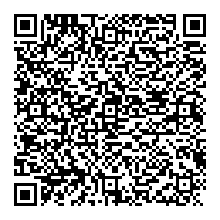

✅ Step 11 done


In [10]:
spends = [r for r in rows if r["type"] == "SPEND"]
totals = {}
for r in spends:
    if r["payload"]["donation"] != "UNFUNDED":
        totals[r["payload"]["donation"]] = totals.get(r["payload"]["donation"], 0) + r["payload"]["amount"]
donation = max(totals, key=totals.get)       # the donation that paid for the most
d = next(x for x in S["donations"] if x["id"] == donation)
mine = [r for r in spends if r["payload"]["donation"] == donation]
used = sum(r["payload"]["amount"] for r in mine)
print(f"DONATION {donation} · {d['donor']} · ₹{d['amount'] / 1e5:.1f} lakh · earmark: {d['earmark']}")
print(f"Used so far: ₹{used / 1e5:.2f} lakh in {len(mine)} payments\n")
handovers = {r["payload"]["trip"]: r for r in rows if r["type"] == "HANDOVER"}
print(pd.DataFrame([{"record": f"#{r['seq']}", "trip": r["payload"]["trip"], "hospital": r["payload"]["hospital"],
                     "category": r["payload"]["category"], "₹": r["payload"]["amount"],
                     "handover": f"✅ min {handovers[r['payload']['trip']]['minute']}"} for r in mine[:6]]).to_string(index=False))
leaf, proof, b = ledger.proof_for(mine[0]["seq"])
print(f"\nMerkle proof for #{mine[0]['seq']}: {'✅ valid' if lm.verify_proof(leaf, proof, b['merkle_root']) else '❌'} "
      f"· anchor: {lm.AMOY_EXPLORER + anchors['tx'] if anchors['tx'] else 'pending (Step 9)'}")
print("\nDonor receipt QR:")
display(qrcode.make(f"SENTINEL donor trace | donation={donation} | record={mine[0]['seq']} | hash={leaf} | "
                    f"root={b['merkle_root']} | tx={anchors['tx'] or 'pending'}").resize((220, 220)))
print("✅ Step 11 done")

## Step 12 · Privacy: one record, five viewers
**Role-based views** (slide 3): the same payment record looks different to each role. Nobody outside the hospital or commander ever sees which patient it was, and even they see only a pseudonym; the real ID stays in a private vault.

In [11]:
rec = mine[0]
other_h = next(h["id"] for h in S["hospitals"] if h["id"] != rec["payload"]["hospital"])
views = {
    "Commander": lm.role_view("Commander", rec),
    f"Hospital {rec['payload']['hospital']} (own)": lm.role_view("Hospital", rec, viewer_hospital=rec["payload"]["hospital"]),
    f"Hospital {other_h} (other)": lm.role_view("Hospital", rec, viewer_hospital=other_h),
    f"Donor of {donation}": lm.role_view("Donor", rec, viewer_donation=donation),
    "Public": lm.role_view("Public", rec),
}
ORDER = ["patient", "hospital", "donation", "category", "amount", "seq", "type", "hash"]
for who, v in views.items():
    shown = v.get("payload", v.get("hidden", v))
    if isinstance(shown, dict):
        shown = {k: shown[k] for k in ORDER if k in shown}
    print(f"{who:<26} → {shown}")
print(f"\nPatient pseudonym {rec['payload']['patient']} → real ID is only in the private vault (keys folder), never on the ledger.")
print("✅ Step 12 done")

Commander                  → {'patient': 'PT-2c7ee2d01e', 'hospital': 'H4', 'donation': 'DN-01', 'category': 'treatment', 'amount': 20000}
Hospital H4 (own)          → {'patient': 'PT-2c7ee2d01e', 'hospital': 'H4', 'donation': 'DN-01', 'category': 'treatment', 'amount': 20000}
Hospital H1 (other)        → another hospital's record
Donor of DN-01             → {'hospital': 'H4', 'donation': 'DN-01', 'category': 'treatment', 'amount': 20000}
Public                     → {'seq': 37, 'type': 'SPEND', 'hash': '6303976905b09c45…'}

Patient pseudonym PT-2c7ee2d01e → real ID is only in the private vault (keys folder), never on the ledger.
✅ Step 12 done


## Step 13 · Export for the website
Saves **ledger_export.json** (records, batches, anchor) for the live website in the final phase. The private vault and keys stay in your Drive's keys folder.

In [12]:
ok, _, msg = ledger.verify_chain()
export = {"records": ledger.rows(), "batches": ledger.batches(), "anchor": anchors, "verified": ok}
with open(f"{DATA_DIR}/ledger_export.json", "w") as f:
    json.dump(export, f, indent=1)
for p in [COPY1, COPY2]:
    if os.path.exists(p):
        os.remove(p)
print(f"Real ledger still {'✅ VALID' if ok else '❌ BROKEN'} · {len(export['records'])} records exported")
print("🎉 Notebook 5 complete. Send Claude screenshots of Steps 4, 7, 9, 10 and 11.")

Real ledger still ✅ VALID · 313 records exported
🎉 Notebook 5 complete. Send Claude screenshots of Steps 4, 7, 9, 10 and 11.


## What you just built (say this to a judge)
> *"Every SENTINEL decision is written to an append-only ledger. Each record's SHA-256 hash includes the previous record's hash, and each actor signs its own records. Patients appear only as pseudonyms. Ambulance handovers are proven with a one-time code whose hash is on the ledger, and every rupee is traced from donation to a verified handover. Every 15 minutes a Merkle root summarises the batch, and the roots are anchored on the Polygon Amoy public blockchain. We showed two attacks: a simple edit is caught by the hash chain, and even a perfect rewrite with stolen keys is caught by the public anchor."*

| Slide says | Where |
|---|---|
| SHA-256 chain, verifier | Steps 3–5 |
| Signed records per actor | Step 4 (Ed25519) |
| QR/OTP proof of handover | Step 6 |
| Tamper alarm | Steps 7 and 10 |
| Merkle batcher | Steps 4 and 8 |
| Public anchor (Polygon Amoy) | Steps 9–10 |
| Donor QR trace | Step 11 |
| No personal data on-chain, pseudonymous IDs, role-based views | Steps 4 and 12 |
| Every manual reallocation ledgered with actor ID | Step 4 (`OVERRIDE`) |